In [1]:
import networkx as nx
import matplotlib.pyplot as plt

defining graphs:
- nx.Graph -> initialises an undirected graph
- nx.DiGraph() -> initialises a directed graph
- nx.MultiGraph() -> initialises an undirected graph with multiple edges
- nx.MultiDiGraph() -> initialises a multigraph(multiple edges between nodes) - but is also directed, i.e. the edges don't go either way but rather one specific way depending on the nature of the graph being defined..

In [2]:
G = nx.Graph() # initialise an undirected graph

In [3]:
# adding edges and nodes to our undirected graph:
# instead of adding nodes and edges separately: G.add_node(1) and G.add_node(2) -> we could create nodes and edges in one step with G.add_edge(1,2)
G.add_edge(1,2)

In [4]:
nx.shortest_path?

Signature:
nx.shortest_path(
    G,
    source=None,
    target=None,
    weight=None,
    method='dijkstra',
    *,
    backend=None,
    **backend_kwargs,
)
Docstring:
Compute shortest paths in the graph.

Parameters
----------
G : NetworkX graph

source : node, optional
    Starting node for path. If not specified, compute shortest
    paths for each possible starting node.

target : node, optional
    Ending node for path. If not specified, compute shortest
    paths to all possible nodes.

weight : None, string or function, optional (default = None)
    If None, every edge has weight/distance/cost 1.
    If a string, use this edge attribute as the edge weight.
    Any edge attribute not present defaults to 1.
    If this is a function, the weight of an edge is the value
    returned by the function. The function must accept exactly
    three positional arguments: the two endpoints of an edge and
    the dictionary of edge attributes for that edge.
    The function must return a nu

extra arguments we could supply to the above fn:
- weight (the weight we are attributing to that edge - could represent: distance, cost, similarity, travel time) | useful say when needing to find the shortest path: for instance using the shortest_path mtd...nx.shortest_path(G, source=..,target=...,weight="weight")....use the weight attribute on edges as the cost
- if no weight is supplied => BFS (breadth-first search)
- if weights -> Djikstra's algorithm
- e.g.. like below...
- nx.shortest_path(....) => general front-door fn in network x for asking:
  - what sequence of nodes get me from here to there as cheaply as possible
  - But, cheaply can mean 2 things:
    - fewest edges (if the graph is treated as unweighted)
    - smallest total edge cost if you tell it which edge attributes stores the cost/weight
- Full functional idea:
  - the shortest_path function signature is essentially:
    - nx.shortest_path(G, source=None, target=None, weight=None, method='dijkstra')
    - networkx documents these main params: G, source, target, weight, and method. it also documents that the return type changes on whether you provide one or both of source and target...
    - Arguments explained:
      - G: the graph object | can be : nx.Graph() for undirected graphs | nx.DiGraph() for directed graphs | weighted or unweighted depending on whether edges have attributes like weight
      - source: the node you want to start from | if you provide source but not target then networkx gives the shortest paths ffrom that one source to all reachable nodes
      - target: destination node | providing both source and target means you get one shortest path as a list of nodes
      - weight: biggest one | weight can be: None, a string or a function 
        - if weight = None, then networkx treats the graph as unweighted. every edge is effectively assumed to have a cost of 1. So, shortest means fewest hops/fewest edges.
        - So the default is None, not a string. 
        - if the weight is a string: e.g. weight="weight", it references the 'weight' attribute of edges defined with G.add_edge(1,2,weight=7)...internally, when u pass weight="weight" to the shprtest path method, you're telling NetworkX : for each edge, look inside its attribute dictionary and use the value stored under the key 'weight'....
        - weight can also be a function:
          - function must accept 3 arguments: the two endpoint nodes and the edge attribute dictionary. then return a numeric cost...
          - e.g.
            - """ def my_cost(u, v, d):
                    return d.get("distance",1) + d.get("toll",0)
            - cost function is evaluated for every node pair considered when determining the shortest path from source to sink...
          - method: tells networkx which weighted shortest-path algorithm to use: e.g dijkstra, or bellman-ford...if the weight is None, network x uses unweighted graph methods and the method argument is ignored. 

--------------------------------------------------------------------------------------------------------------------------------------------------
- **end of break - back to creating graph edges**
  - when defining an edge...in addition to the weight, any custom metadata can be provided
    - G.add_edge(1,2,relation="friends",since=2020)
      - this edge now carries in its attribute dictionary: {relation:'friends',since=2020}
      - this is useful for: social networks | knowledge graphs | time-based networks | probabilities
      - can also use the dictionary syntax: G.add_edge(1,2, **{"weight":5, "capacity":10})
      - multiple attribute examples: G.add_edge(1,2,weight=7,capacity=15,label="road")
        - the above might mean, distance=7km, max traffic = 15 cars, and type = road
      - You can also update existing edges:
        - if an edge already exists, can update it with: G.add_edge(1,2,weight=10) -> it updates attributes and doesn't duplicate edges
  - Inspecting edge attributes:
    - G.edges(data=True) = returns > [(1,2,{'weight':3.5})] or inspect with G[1][2] -> providing nodes


In [5]:
G.edges(data=True)

EdgeDataView([(1, 2, {})])

In [6]:
G[1][2]

{}

In [7]:
G.add_edge(2,3,weight=0.9)

In [8]:
G[2][3]

{'weight': 0.9}

In [9]:
G.add_edge("A","B")
G.add_edge("B","B")
G.add_node("C")
G.add_node(print)

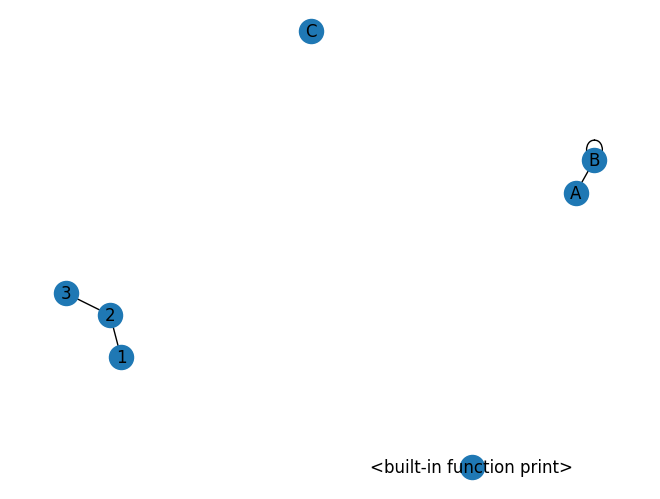

In [10]:
nx.draw_spring(G, with_labels=True)
plt.show()

notes: nx.draw_spring draws a graph using a force-directed spring layout. | it places nodes in 2D so that connected nodes are closer together, like they are tied by springs...| 
- Intuition:
  - edges = springs pulling nodes together | nodes = charged particles pushing each other apart 
  - so connected nodes are pulled closer | unrelated nodes are pushed apart | result is a nice readable layout 

Instead of adding edges like above, we could add them from an edge list instead....

In [11]:
edge_list = [(1,2), (2,3), (3,4), (3,5), (4,6), (6,7)]

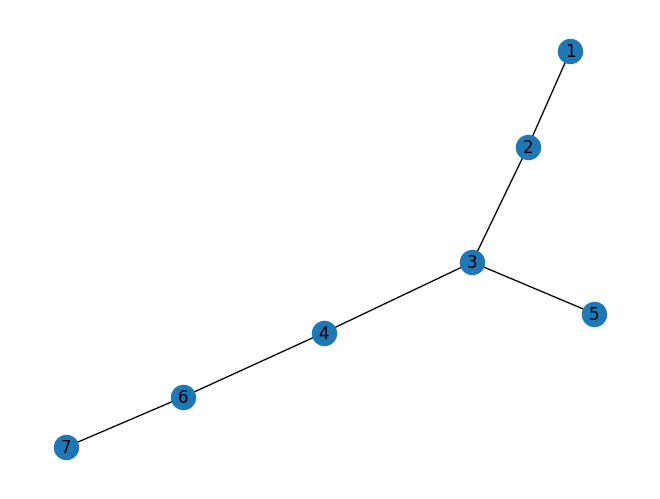

In [12]:
G = nx.from_edgelist(edge_list)

nx.draw_spring(G, with_labels=True)

or...we could do it this way..

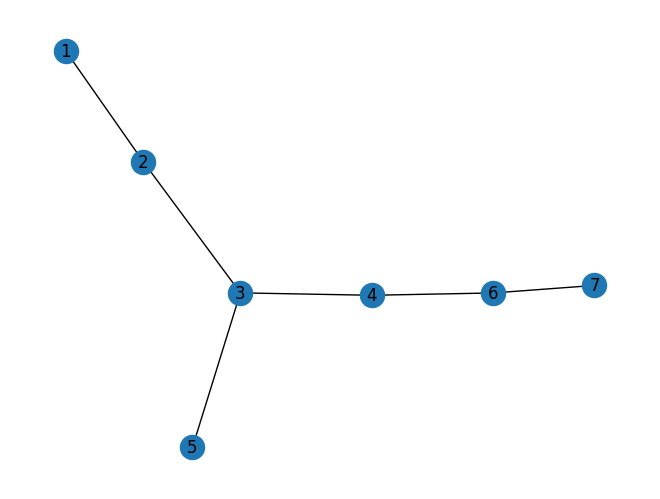

In [13]:
G = nx.Graph()
G.add_edges_from(edge_list)

nx.draw_spring(G, with_labels=True)

- in relation to the above approach of adding edges...
  - you can also include edge attributes:
    - edge_list = [
        (1,2,{"weight":5}),
        (2,3,{"weight":2})
    ]
    - G = nx.from_edgelist(edge_list)
- this approach works for directed graphs as well...
- G = nx.DiGraph() | G.add_edges_from(edge_list) 
- edge_list = [(1,2), (2,3), (3,1)] | this creates: 1 -> 2 -> 3 -> 1
- now using from_edgelist by default creates an undirected graph | to make it directed, you must specify:
  - G = nx.from_edgelist(edge_list, create_using=nx.DiGraph())

we can represent these graphs in different ways:
- can use the adjacency matrix...
- fetch the representation as follows:

In [14]:
print(nx.adjacency_matrix(G))

<Compressed Sparse Row sparse array of dtype 'int64'
	with 12 stored elements and shape (7, 7)>
  Coords	Values
  (0, 1)	1
  (1, 0)	1
  (1, 2)	1
  (2, 1)	1
  (2, 3)	1
  (2, 4)	1
  (3, 2)	1
  (3, 5)	1
  (4, 2)	1
  (5, 3)	1
  (5, 6)	1
  (6, 5)	1


adjacency matrix with numpy...

In [15]:
import numpy as np

creating a numpy array to hold the relationship/connection..where 1 represents a valid connection between nodes:

In [16]:
a = np.array([
    [0, 1, 0],
    [1, 1, 1],
    [0, 0, 0]
]) # assume we have nodes a,b, and c -  then from the above connections: a is connected to b | b is connected to itself, and a and c.....c isn't connected to either nodes..so the above is a directed graph..

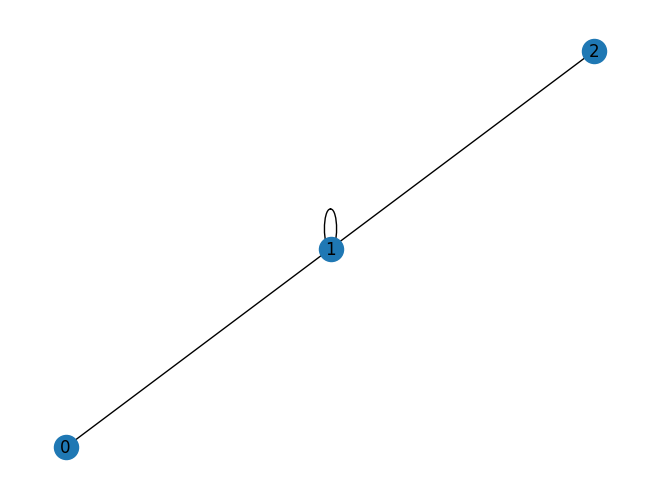

In [17]:
G = nx.from_numpy_array(a)

nx.draw_spring(G, with_labels=True)

can also use nx.draw_circular, which:
- places all nodes evenly on a circle, ignoring structure
  - idea: 
    - nodes placed at equal angles around a circle | edges drawn afterward | no clustering logic

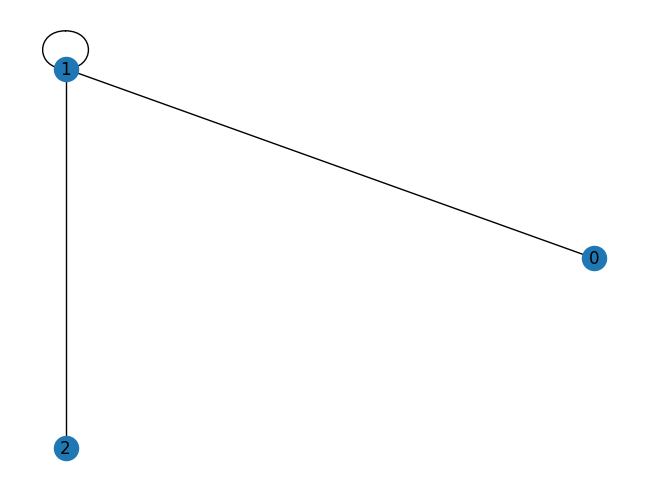

In [18]:
nx.draw_circular(G, with_labels=True)

other drawing variations:
- draw_planar: attempts to draw the graph **without any edge crossings** - it only works if the graph is planar (can be drawn without any edges crossing) otherwise will raise an error. | draw_spectral: uses eigenvectors of the laplacian to position nodes - its mathematically based on spectral embedding | draw_random : places nodes randomly in space (nodes scattered randomly, edges drawn afterwards) | draw_shell: places nodes in concentric circles (shells)

In [19]:
edge_list = [(1,2), (1,3), (1,4), (2,3), (2,4), (3,4)]

G = nx.Graph()
G.add_edges_from(edge_list)

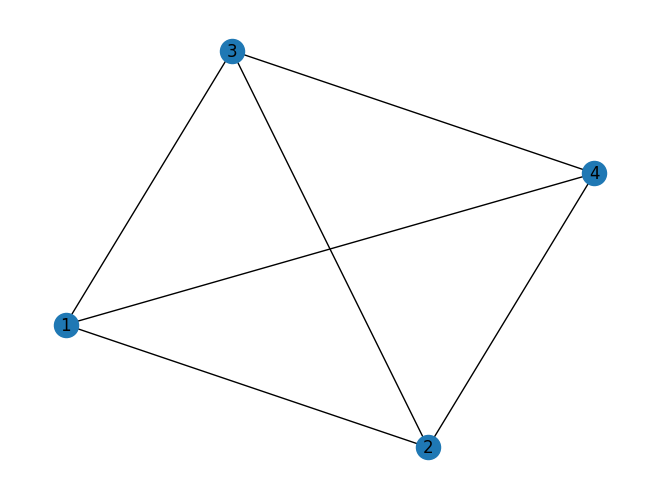

In [20]:
nx.draw_spring(G, with_labels=True)

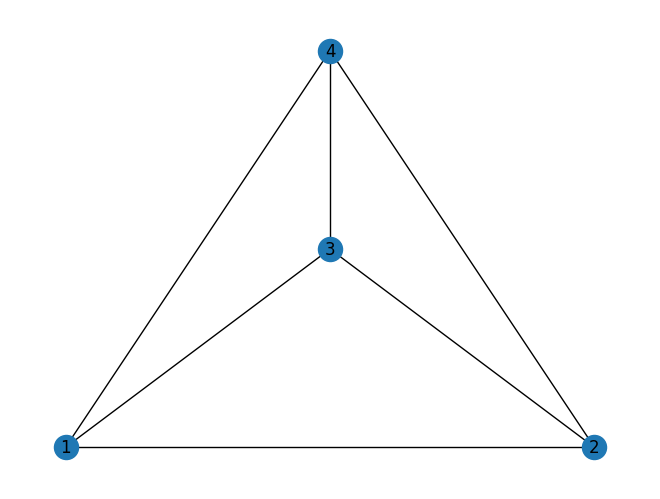

In [21]:
nx.draw_planar(G, with_labels=True)

complete graph:
- nx.complete_graph: creates a graph where every node is connected to every other node...

In [25]:
G = nx.complete_graph(5)


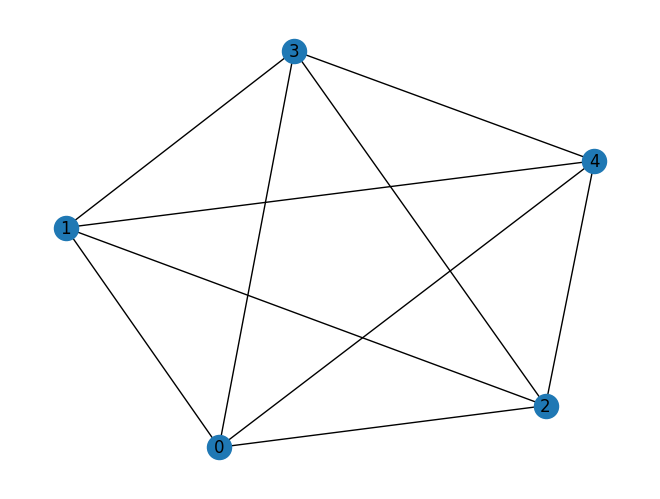

In [26]:
nx.draw_spring(G, with_labels=True)

In [27]:
nx.draw_planar(G, with_labels=True)

NetworkXException: G is not planar.

get information about a graph...
- extract the degree of a graph

In [28]:
edge_list = [(1,2),(1,3),(1,4),(2,3),(2,4),(3,4)]
G = nx.Graph()
G.add_edges_from(edge_list)

In [32]:
print(dict(G.degree)[2])

3


the degree of node 2, is 3

In [33]:
edge_list = [(1,2),(2,3),(3,4),(3,5),(4,6),(6,7)]

G = nx.Graph()
G.add_edges_from(edge_list)

In [35]:
print(dict(G.degree)[3])

3


for directed graphs - we have in degree and out degree...

In [36]:
edge_list = [(1,2), (2,3), (3,4), (3,5), (4,6), (6,7)]

G = nx.DiGraph()
G.add_edges_from(edge_list)

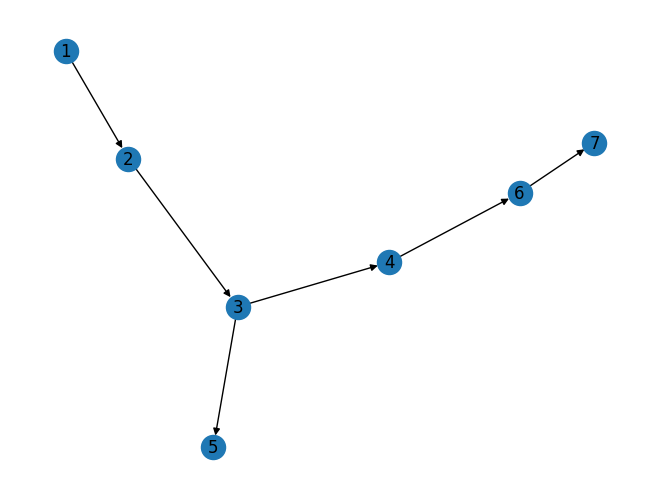

In [37]:
nx.draw_spectral(G, with_labels=True)

In [38]:
print(dict(G.in_degree)[3])

1


In [39]:
print(dict(G.out_degree)[3])

2


shortest path

In [40]:
edge_list = [(1,2),(2,3),(3,4),(3,5),(4,6),(6,7),(2,8),(8,9),(9,4)]

In [41]:
G = nx.Graph()
G.add_edges_from(edge_list)

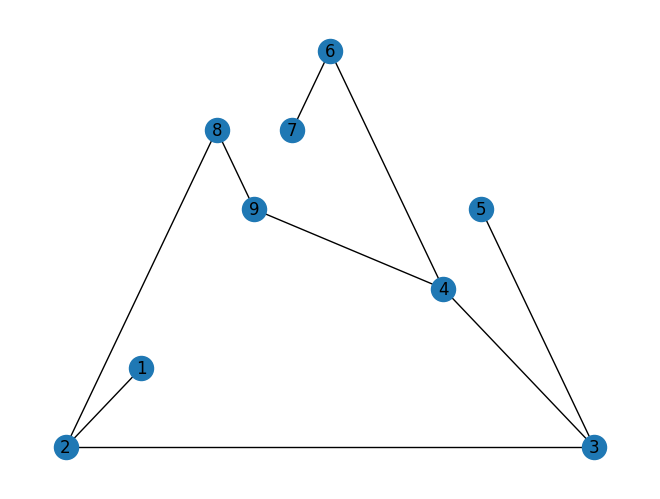

In [42]:
nx.draw_planar(G, with_labels=True)

computing the shortest path

In [44]:
nx.shortest_path(G,2,4)

[2, 3, 4]

Updating graphs in networkx:
- Suppose we created:
    - G.add_edge(1,2,weight=5,label="road")
    - update: G[1][2]["weight"] = 10
    - can also add new metadata: G[1][2]["capacity"] = 10
- method b: can also update using the add_edge function:
  - G.add_edge(1,2,weight=NEW_WEIGHT)
- method c: using the .edges mtd: G.edges[1,2]['weight'] = NEW WEIGHT

- updating node metadata:
  - G.add_node(1, color='red') => creating a node
  - G.nodes[1]['color'] = 'blue' | metadata updated

- removing an edge:
  - G.remove_edge(1,2) | removes edge between nodes 1 and 2

- removing multiple edges:
  - G.remove_edges_from([(1,2),(2,3)])

- removing a node:
  - G.remove_node(2)

- updating multiple attributes at once:
  - G[1][2].update({"weight":50,"label":"highway"})

-  checking before updating:
   - if G.has_edge(1,2):
        G[1][2]['weight'] = 10

In [45]:
G.remove_edge(2,3)

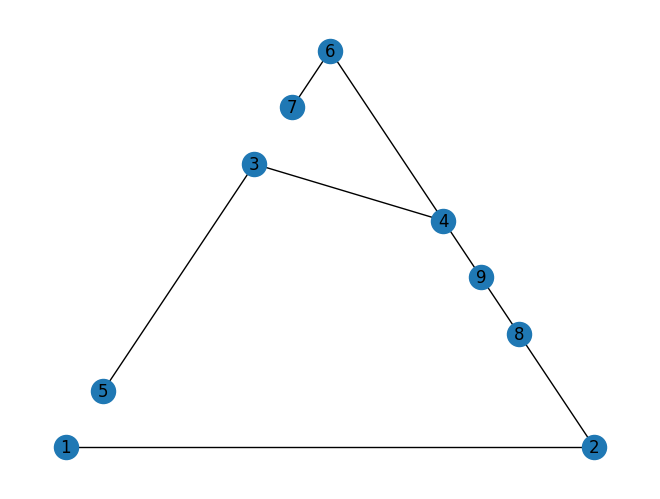

In [46]:
nx.draw_planar(G, with_labels=True)

In [47]:
nx.shortest_path(G, 2, 4)

[2, 8, 9, 4]

Centrality:
- means which nodes are the most important or influential based on the network structure...
- In network x, centrality measures score each node according to different notions of importance

- Why centrality matters:
  - Think of a social network:
    - Who has the most friends? | Who connects different groups? | Who is closest to everyone? | Who is connected to other influential people ?

**Degree Centrality:**
- idea: nodes with the most connections are important

In [48]:
nx.degree_centrality(G)

{1: 0.125,
 2: 0.25,
 3: 0.25,
 4: 0.375,
 5: 0.125,
 6: 0.25,
 7: 0.125,
 8: 0.25,
 9: 0.25}

interpretration:
- high value -> many neighbors
- low value -> few connections

Betweenness centrality:
- idea: nodes that lie on many shortest paths are important

In [49]:
nx.betweenness_centrality(G)

{1: 0.0,
 2: 0.25,
 3: 0.25,
 4: 0.7142857142857142,
 5: 0.0,
 6: 0.25,
 7: 0.0,
 8: 0.42857142857142855,
 9: 0.5357142857142857}

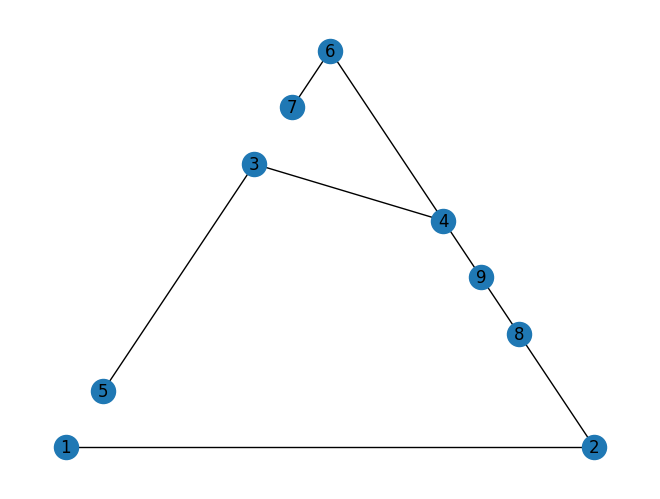

In [50]:
nx.draw_planar(G, with_labels=True)

as in the image, node 9 lies on many shortest paths, which justifies its high centrality value

Closeness Centrality:
- Idea: Nodes closest to all others are important

In [51]:
nx.closeness_centrality(G)

{1: 0.25,
 2: 0.32,
 3: 0.38095238095238093,
 4: 0.5,
 5: 0.2857142857142857,
 6: 0.38095238095238093,
 7: 0.2857142857142857,
 8: 0.4,
 9: 0.47058823529411764}

measures: inverse of average shortest-path distance to all nodes. | HIgh closeness: quick access to entire network and is centrally located.

Eigenvector centrality:
- Idea: Important nodes are connected to other important nodes.
- This is recursive:
  - being connected to high-scoring nodes oncreases your score

In [52]:
nx.eigenvector_centrality(G)

{1: 0.09759916309479044,
 2: 0.19930250257994486,
 3: 0.3696158240670783,
 4: 0.5737873738173097,
 5: 0.18099917478792302,
 6: 0.3696158240670783,
 7: 0.18099917478792302,
 8: 0.3093881873362542,
 9: 0.43248907230564826}

page rank:
- variant of eigenvector centrality
- important if:
  - connected to important nodes
  - weighted by link importance
- for ranking webpages and citation networks

more on centrality...example...

In [53]:
G1 = nx.complete_graph(5)
G2 = nx.complete_graph(5)
G2 = nx.relabel_nodes(G2, {0:"A", 1:"B", 2:"C", 3:"D", 4:"E"})
G_connector = nx.from_edgelist([(4, "X"),("X", "A")])

In [54]:
# use the compose_all function to connect multiple graphs
G = nx.compose_all([G1, G2, G_connector])

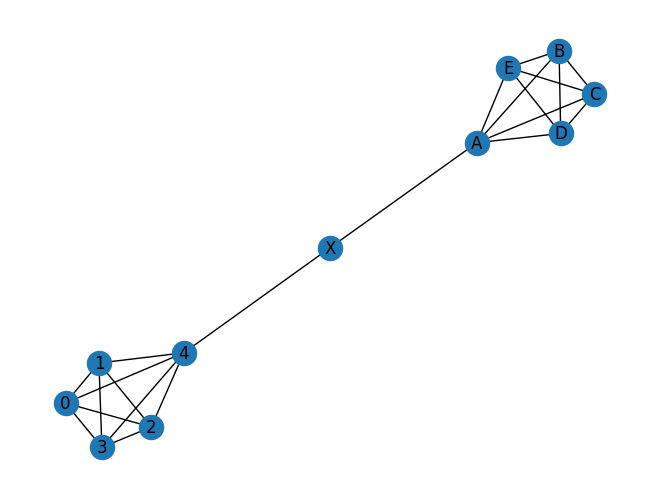

In [59]:
nx.draw_spring(G, with_labels=True)

In [60]:
nx.degree_centrality(G)

{0: 0.4,
 1: 0.4,
 2: 0.4,
 3: 0.4,
 4: 0.5,
 'A': 0.5,
 'B': 0.4,
 'C': 0.4,
 'D': 0.4,
 'E': 0.4,
 'X': 0.2}

In [62]:
nx.betweenness_centrality(G)

{0: 0.0,
 1: 0.0,
 2: 0.0,
 3: 0.0,
 4: 0.5333333333333333,
 'A': 0.5333333333333333,
 'B': 0.0,
 'C': 0.0,
 'D': 0.0,
 'E': 0.0,
 'X': 0.5555555555555556}

In [63]:
nx.density(G) # how many edges do we have divided by total number of possible edges

0.4

In [64]:
nx.diameter(G) # measures: the longest shortest path between any two nodes

4

find bridges..
- single points of failure in the graph
- when disconnected split the graph into 2

In [66]:
list(nx.bridges(G))

[(4, 'X'), ('A', 'X')]

In [67]:
list(nx.local_bridges(G))

[(4, 'X', inf), ('A', 'X', inf)]